In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
%connect_info

{"key":"10d5532f-d0f6-46ce-b8e6-66540ec8e033","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9010,"control_port":9011,"shell_port":9012,"stdin_port":9013,"iopub_port":9014,"kernel_name":"python3115jvsc74a57bd0e51a11a35a9cffe10dbeeadb5683ca5855e70b329073972aeeab17b98f2e31e9"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing c:\Users\Ngo_Duc_Phu\AppData\Roaming\jupyter\runtime\kernel-v3e40710eb8dd1b544e7fa121ab582bdafa46396a8.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


In [ ]:
#Import the date from Full_Dataset.csv

df_all = pd.read_csv('Full_Dataset.csv', header=0)
df_all.rename(columns={'Date': 'time'}, inplace=True)
df_all['time'] = pd.to_datetime(df_all['time'], dayfirst=True)
df_all.set_index('time', inplace=True)

df_all = df_all.groupby(level=0).mean()
data = df_all[['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']].resample('1h').mean().ffill()
data.columns = ['belpex', 'solar', 'wind', 'load']
# data contains: belpex, solar, wind, load

# Define lookback window
lookback = 7   # use past 7 days to predict next day

# Build 3D input array
features = ['belpex', 'solar', 'wind', 'load']
n_features = len(features)

X_lstm, Y_lstm = [], []

# Scale raw data first
scaler_lstm_x = StandardScaler()
scaler_lstm_y = StandardScaler()

data_scaled = data.copy()
data_scaled[features] = scaler_lstm_x.fit_transform(data[features])
price_scaled = scaler_lstm_y.fit_transform(
    data['belpex'].values.reshape(-1, 1)
)

days = len(data) // 24

for d in range(lookback, days):
    # Past 7 days of all features (hourly)
    past = data_scaled[features].values[(d-lookback)*24 : d*24]
    # Shape: (lookback×24, n_features) = (168, 4)
    
    # Next 24 hours of prices
    future = price_scaled[d*24 : (d+1)*24]
    # Shape: (24, 1)
    
    X_lstm.append(past)
    Y_lstm.append(future.flatten())

X_lstm = np.array(X_lstm)   # shape: (n_days, 168, 4)
Y_lstm = np.array(Y_lstm)   # shape: (n_days, 24)

print(f"X shape: {X_lstm.shape}")
print(f"Y shape: {Y_lstm.shape}")

X shape: (1874, 168, 4)
Y shape: (1874, 24)


In [6]:
from sklearn.model_selection import train_test_split

# Same 70/15/15 split as your ANN
X_tv, X_test, Y_tv, Y_test = train_test_split(
    X_lstm, Y_lstm, test_size=0.15, shuffle=False
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_tv, Y_tv, test_size=0.176, shuffle=False
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (1311, 168, 4)
Val:   (281, 168, 4)
Test:  (282, 168, 4)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_lstm = Sequential([
    # First LSTM layer — return sequences for stacking
    LSTM(64, 
         return_sequences=True, 
         input_shape=(168, 4)),   # (timesteps, features)
    Dropout(0.2),
    
    # Second LSTM layer
    LSTM(32, 
         return_sequences=False),
    Dropout(0.2),
    
    # Output layer — 24 hourly prices
    Dense(24, activation='linear')
])

model_lstm.compile(
    loss='mse',
    optimizer=Adam(learning_rate=0.001),
    metrics=['mae']
)

model_lstm.summary()

c:\Users\Ngo_Duc_Phu\Downloads\Python_code\Smart_distribution_project\SmartDistributionSystems\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,872 (120.59 KB)

 Trainable params: 30,872 (120.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Training using Callbacks (Not sure how does it work yet)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

history_lstm = model_lstm.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.9176 - mae: 0.6216 - val_loss: 0.1928 - val_mae: 0.3083 - learning_rate: 0.0010
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.4321 - mae: 0.4170 - val_loss: 0.1506 - val_mae: 0.2683 - learning_rate: 0.0010
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.3106 - mae: 0.3612 - val_loss: 0.1319 - val_mae: 0.2515 - learning_rate: 0.0010
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.2662 - mae: 0.3348 - val_loss: 0.1267 - val_mae: 0.2429 - learning_rate: 0.0010
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.2431 - mae: 0.3227 - val_loss: 0.1277 - val_mae: 0.2456 - learning_rate: 0.0010
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.2238 - mae: 0.3126 - val_loss: 0.1265 - val_mae: 0.2413 - learning_rate: 0.0010
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.2137 - mae: 0.3021 - val_loss: 0.1191 - val_mae: 0.2331 - learning_rate: 0.0010
Epoch 

In [19]:
# Generate predictions
pred_scaled = model_lstm.predict(X_test)

# Inverse transform
pred_real = scaler_lstm_y.inverse_transform(pred_scaled)
actual_real = scaler_lstm_y.inverse_transform(Y_test)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(actual_real, pred_real)
rmse = np.sqrt(mean_squared_error(actual_real, pred_real))
mask = actual_real != 0
mape = np.mean(np.abs(
    (actual_real[mask] - pred_real[mask]) / actual_real[mask]
)) * 100

smape = np.mean(2 * np.abs(actual_real - pred_real) / (np.abs(actual_real) + np.abs(pred_real))) * 100
print("\n--- LSTM Performance ---")
print(f"MAE:  {mae:.2f}  €/MWh")
print(f"RMSE: {rmse:.2f} €/MWh")
print(f"MAPE yeah this is wrong: {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

--- LSTM Performance ---
MAE:  19.06  €/MWh
RMSE: 26.94 €/MWh
MAPE yeah this is wrong: 1525288348844179.00%
sMAPE: 37.07%


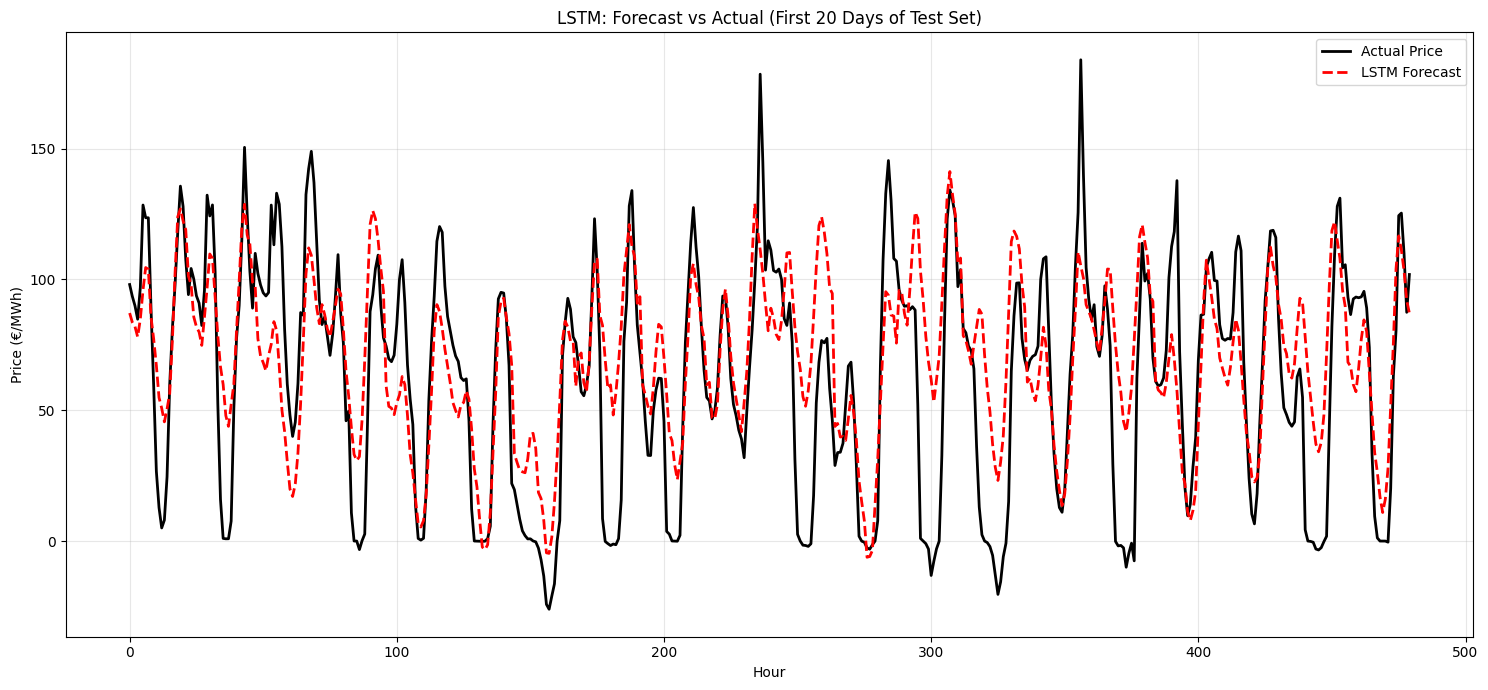

In [16]:
import matplotlib.pyplot as plt

n_plot = 72  # first 3 days

plt.figure(figsize=(15, 7))
plt.plot(actual_real[:20].flatten(),
         label='Actual Price',
         color='black', linewidth=2)
plt.plot(pred_real[:20].flatten(),
         label='LSTM Forecast',
         color='red', linestyle='--', linewidth=2)

plt.title('LSTM: Forecast vs Actual (First 20 Days of Test Set)')
plt.xlabel('Hour')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
#Save the model
model_lstm.save("./trained_model/LTSM_model_1.keras")

#Save the scalers because they are critical to the model usage
import pickle
with open('./trained_model/LTSM_scaler_x.pkl', 'wb') as f:
    pickle.dump(scaler_lstm_x, f)

with open('./trained_model/LTSM_scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_lstm_y, f)

In [ ]:
#Reload the model
from tensorflow.keras.models import load_model

model_lstm_loaded = load_model('model_lstm.keras')

#Load the scalers
with open('./trained_model/LTSM_scaler_x.pkl', 'rb') as f:
    scaler_lstm_x = pickle.load(f)

with open('./trained_model/LTSM_scaler_y.pkl', 'rb') as f:
    scaler_lstm_y = pickle.load(f)

# Verify
model_lstm_loaded.summary()

# Predict immediately
X_test_scaled    = scaler_x.transform(X_test)
pred_scaled = model_lstm_loaded.predict(X_test_scaled)
pred_real   = scaler_lstm_y.inverse_transform(pred_scaled)